In [117]:
# Import required libraries
import re
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Set plot style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [118]:
# Define experiment parameters
pysr_base_path = "pysr_syn2"
lasr_base_path = "lasr_syn2"

# PySR iterations mapping
pysr_iterations = {
    'exp_0': 10,
    'exp_1': 20,
    'exp_2': 40,
    'exp_3': 100,
    'exp_4': 400,
    'exp_5': 1000
}

# LASR experiment labels and colors from loss_comparison_analysis.ipynb
lasr_labels = {
    0: 'Llama3.2',
    5: 'Llama3.2 pw',
    
    1: 'Qwen3-8B',
    6: 'Qwen3-8B pw',
    
    2: 'Qwen3-8B-think',
    7: 'Qwen3-8B-think pw',
    
    3: 'DeepSeek V3',
    8: 'DeepSeek V3 pw',
    10: 'DeepSeek V3 pw40i',
    11: 'DeepSeek V3 pw*',
    
    4: 'DeepSeek R1',
    12: 'DeepSeek R1 pw',
}

# Define gradient colors for each group
def generate_gradient_colors(base_color, n_shades):
    """Generate gradient colors from light to dark for a base color."""
    import matplotlib.colors as mcolors
    rgb = mcolors.to_rgb(base_color)
    colors = []
    for i in range(n_shades):
        # Create gradient from light (0.3) to dark (1.0)
        factor = 0.3 + (0.7 * i / (n_shades - 1)) if n_shades > 1 else 1.0
        # Mix with white for lighter shades
        color = tuple(1 - (1 - c) * factor for c in rgb)
        colors.append(mcolors.to_hex(color))
    return colors

# Colors for each experiment
exp_colors = {
    # PySR colors - gradient from light red to dark red
    'pysr_10': '#ffcccc',    # Very light red
    'pysr_20': '#ff9999',    # Light red
    'pysr_40': '#ff6666',    # Medium light red
    'pysr_100': '#ff3333',   # Medium red
    'pysr_400': '#cc0000',   # Dark red
    'pysr_1000': '#800000',  # Very dark red
}

# Generate gradient colors for each LLM group
llama_colors = generate_gradient_colors('#1f77b4', 2)  # Blue gradient
qwen_colors = generate_gradient_colors('#ff7f0e', 2)   # Orange gradient
qwen_think_colors = generate_gradient_colors('#2ca02c', 2)  # Green gradient
deepseek_v3_colors = generate_gradient_colors('#9467bd', 4)  # Purple gradient
deepseek_r1_colors = generate_gradient_colors('#8c564b', 2)  # Brown gradient

# Assign colors to experiments
exp_colors.update({
    # Llama3.2 group
    0: llama_colors[0],      # Llama3.2 (light blue)
    5: llama_colors[1],      # Llama3.2 pw (dark blue)
    
    # Qwen3-8B group
    1: qwen_colors[0],       # Qwen3-8B (light orange)
    6: qwen_colors[1],       # Qwen3-8B pw (dark orange)
    
    # Qwen3-8B-think group
    2: qwen_think_colors[0], # Qwen3-8B-think (light green)
    7: qwen_think_colors[1], # Qwen3-8B-think pw (dark green)
    
    # DeepSeek V3 group
    3: deepseek_v3_colors[0],  # DeepSeek V3 (lightest purple)
    8: deepseek_v3_colors[1],  # DeepSeek V3 pw (light purple)
    10: deepseek_v3_colors[2], # DeepSeek V3 pw40i (dark purple)
    11: deepseek_v3_colors[3], # DeepSeek V3 pw* (darkest purple)
    
    # DeepSeek R1 group
    4: deepseek_r1_colors[0],  # DeepSeek R1 (light brown)
    12: deepseek_r1_colors[1], # DeepSeek R1 pw (dark brown)
})

In [119]:
equation_info = {
    1: {
        'name': 'Squared-Sine-Exp-Log',
        'formula': 'sin(x*y)² * exp(-z/2) + log(1 + w)',
        'description': 'A squared sinusoidal product with exponential decay plus logarithmic term'
    },
    2: {
        'name': 'Softplus-Cosine Product',
        'formula': 'log(1 + exp(x)) * cos(y*z)',
        'description': 'A softplus function multiplied by a cosine of product'
    },
    3: {
        'name': 'Root-SquaredSine-ExpCos',
        'formula': 'sqrt(x*y) * sin(z)² + exp(-w) * cos(x)',
        'description': 'A square root of product with squared sine plus exponential decay times cosine'
    },
    4: {
        'name': 'Linear-Cosine-Log',
        'formula': 'x*cos(y) + log(1 + z*w)',
        'description': 'A linear cosine term combined with logarithm of product'
    },
    5: {
        'name': 'Exp-Ratio-Sine-Quad',
        'formula': 'exp(x/y) * sin(z) / (1 + w²)',
        'description': 'An exponential ratio multiplied by sine and normalized by quadratic term'
    },
    6: {
        'name': 'Squared-Sum-Exp-Sine',
        'formula': '(x + y)² * exp(-z/3) + sin(w)',
        'description': 'A squared sum with exponential decay plus sine term'
    },
    7: {
        'name': 'SquaredSine-Sigmoid-Log',
        'formula': 'sin(x*y)² / (1 + exp(-z)) + log(1 + x²)',
        'description': 'A squared sine product normalized by sigmoid plus logarithmic quadratic'
    },
    8: {
        'name': 'SquaredLog-Cosine-SquaredSine',
        'formula': 'log(x*y + 1)² * cos(z) - sin(w)²',
        'description': 'A squared logarithm of shifted product times cosine minus squared sine'
    },
    9: {
        'name': 'Exp-Sum-SquaredSine-Ratio',
        'formula': 'sqrt(exp(x) + exp(y)) * sin(z/w)²',
        'description': 'A square root of exponential sum multiplied by squared sine of ratio'
    },
    10: {
        'name': 'Linear-Trig-Exp',
        'formula': 'x*sin(y) + z*cos(w) + exp(-v/2)',
        'description': 'A linear combination of trigonometric terms with exponential decay'
    }
}

In [120]:
# Extract loss data function
def extract_loss_from_summary(file_path):
    """Extract loss values for each equation from a summary file."""
    losses = {}
    
    if not os.path.exists(file_path):
        return losses
    
    with open(file_path, 'r') as f:
        content = f.read()
    
    # Find all equation sections
    equation_sections = re.findall(r'GT Equation #(\d+):.*?Score: ([\d.e-]+), Loss: ([\d.e-]+)', content, re.DOTALL)
    
    for eq_num, score, loss in equation_sections:
        eq_num = int(eq_num)
        loss = float(loss)
        losses[eq_num] = loss
    
    return losses

# Extract PySR data
pysr_data = {}
for exp_name, iterations in pysr_iterations.items():
    exp_path = f"{pysr_base_path}/{exp_name}/summary.txt"
    losses = extract_loss_from_summary(exp_path)
    if losses:
        pysr_data[iterations] = losses
        print(f"PySR {iterations} iterations: {len(losses)} equations found")

# Extract LASR data
lasr_data = {}
for exp_num, label in lasr_labels.items():
    exp_path = f"{lasr_base_path}/exp_{exp_num}/summary.txt"
    losses = extract_loss_from_summary(exp_path)
    if losses:
        lasr_data[exp_num] = losses
        print(f"LASR {label}: {len(losses)} equations found")

PySR 10 iterations: 10 equations found
PySR 20 iterations: 10 equations found
PySR 40 iterations: 10 equations found
PySR 100 iterations: 10 equations found
PySR 400 iterations: 10 equations found
PySR 1000 iterations: 10 equations found
LASR Llama3.2: 10 equations found
LASR Llama3.2 pw: 8 equations found
LASR Qwen3-8B: 10 equations found
LASR Qwen3-8B pw: 8 equations found
LASR Qwen3-8B-think: 10 equations found
LASR Qwen3-8B-think pw: 8 equations found
LASR DeepSeek V3: 10 equations found
LASR DeepSeek V3 pw: 8 equations found
LASR DeepSeek V3 pw40i: 3 equations found
LASR DeepSeek V3 pw*: 5 equations found
LASR DeepSeek R1: 10 equations found
LASR DeepSeek R1 pw: 2 equations found


In [121]:
# Find all equations across experiments
all_equations = set()
for losses in pysr_data.values():
    all_equations.update(losses.keys())
for losses in lasr_data.values():
    all_equations.update(losses.keys())
all_equations = sorted(list(all_equations))

print(f"\nTotal equations found: {len(all_equations)}")
print(f"Equations: {all_equations}")


Total equations found: 10
Equations: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


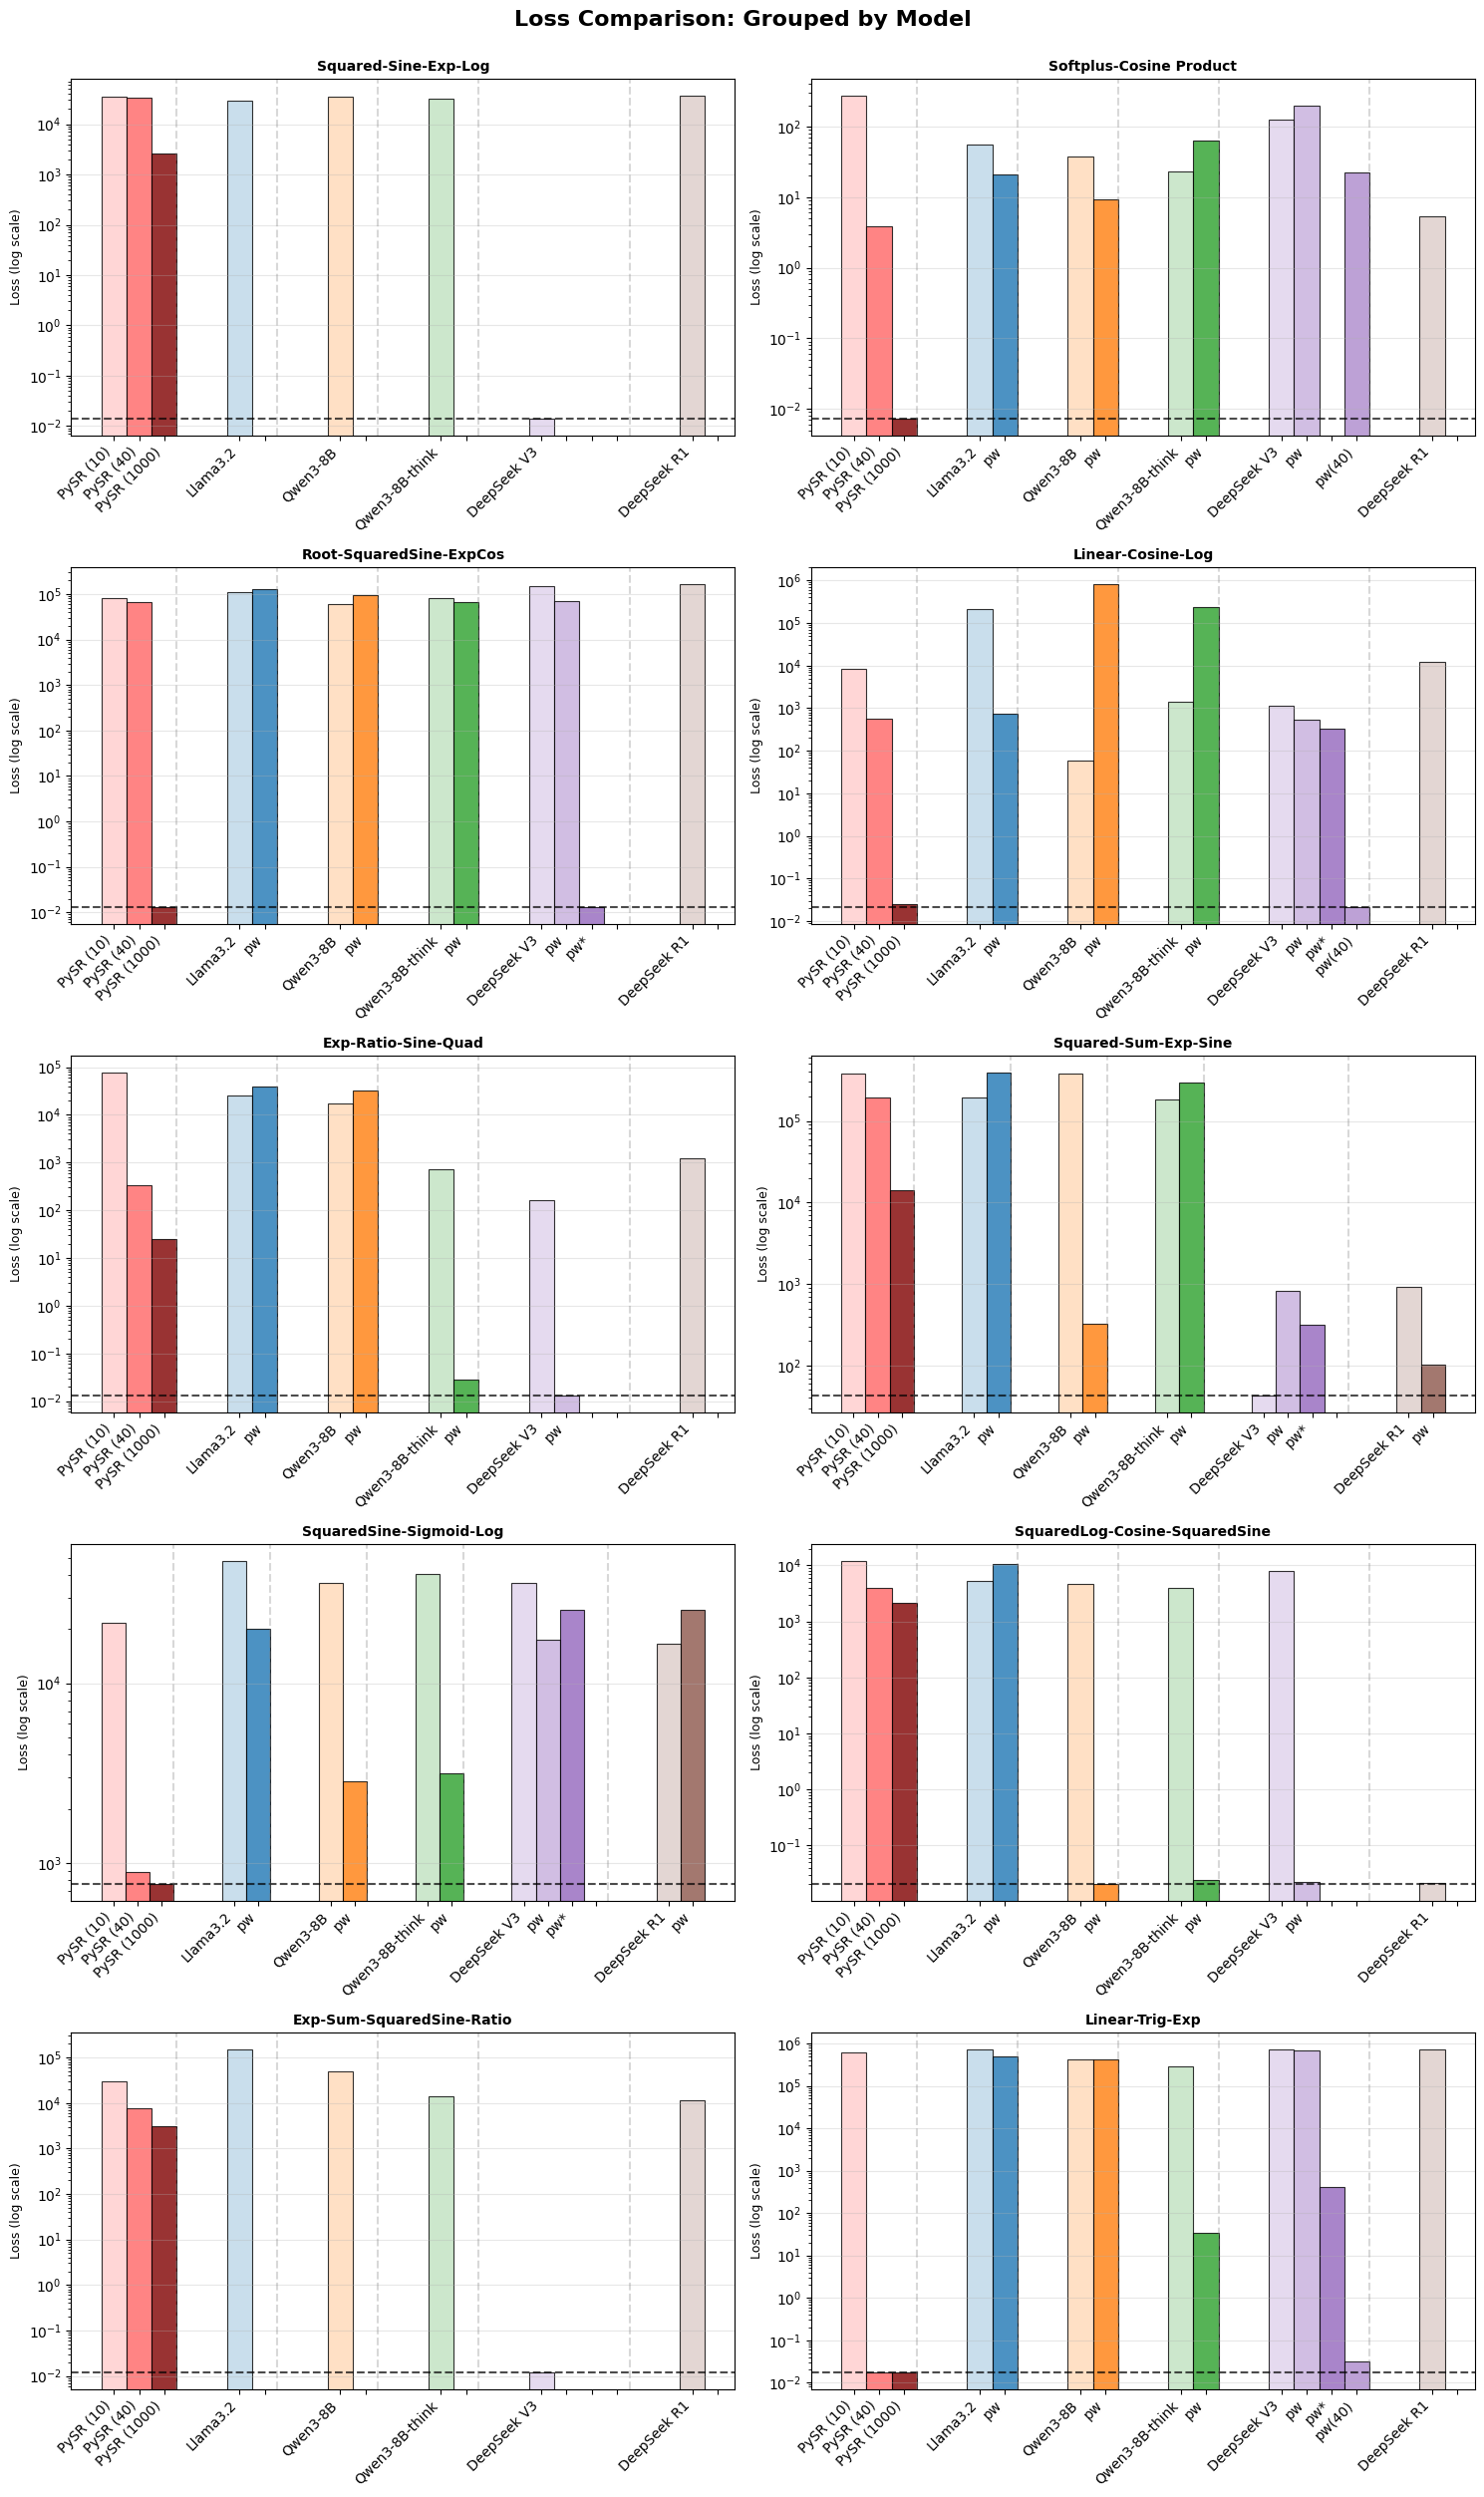

In [122]:
# Create grouped bar charts with proper spacing based on lasr_labels grouping
n_equations = len(all_equations)
n_cols = 2  # Changed from 5 to 2
n_rows = 5  # Changed from 2 to 5

# Function to simplify labels
def simplify_label(exp_type, exp_key, original_label):
    """Simplify labels: keep full name for pure experiments, only suffix for others"""
    if exp_type == 'pysr':
        return f'PySR ({exp_key})'
    else:  # lasr
        # Pure experiments (no suffix)
        if exp_key in [0, 1, 2, 3, 4]:
            return original_label
        # Experiments with suffix - show only suffix
        else:
            if 'pw40i' in original_label:
                return 'pw(40)'
            elif 'pw*' in original_label:
                return 'pw*'
            elif 'pw' in original_label:
                return 'pw'
            else:
                return original_label

# Define experiment groups based on lasr_labels structure
experiment_groups = {
    'PySR Baselines': {
        'experiments': [],
        'colors': []
    },
    'Llama3.2': {
        'experiments': [],
        'colors': []
    },
    'Qwen3-8B': {
        'experiments': [],
        'colors': []
    },
    'Qwen3-8B-think': {
        'experiments': [],
        'colors': []
    },
    'DeepSeek V3': {
        'experiments': [],
        'colors': []
    },
    'DeepSeek R1': {
        'experiments': [],
        'colors': []
    }
}

# Populate PySR group - add all available PySR iterations
all_pysr_iterations = [10, 40, 1000]
for iterations in all_pysr_iterations:
    experiment_groups['PySR Baselines']['experiments'].append(('pysr', iterations, f'PySR ({iterations})'))
    experiment_groups['PySR Baselines']['colors'].append(exp_colors[f'pysr_{iterations}'])

# Populate LASR groups based on the exact grouping in lasr_labels
# Llama3.2 group
for exp_num in [0, 5]:
    if exp_num in lasr_labels:
        experiment_groups['Llama3.2']['experiments'].append(('lasr', exp_num, lasr_labels[exp_num]))
        experiment_groups['Llama3.2']['colors'].append(exp_colors[exp_num])

# Qwen3-8B group
for exp_num in [1, 6]:
    if exp_num in lasr_labels:
        experiment_groups['Qwen3-8B']['experiments'].append(('lasr', exp_num, lasr_labels[exp_num]))
        experiment_groups['Qwen3-8B']['colors'].append(exp_colors[exp_num])

# Qwen3-8B-think group
for exp_num in [2, 7]:
    if exp_num in lasr_labels:
        experiment_groups['Qwen3-8B-think']['experiments'].append(('lasr', exp_num, lasr_labels[exp_num]))
        experiment_groups['Qwen3-8B-think']['colors'].append(exp_colors[exp_num])

# DeepSeek V3 group
for exp_num in [3, 8, 11, 10]:
    if exp_num in lasr_labels:
        experiment_groups['DeepSeek V3']['experiments'].append(('lasr', exp_num, lasr_labels[exp_num]))
        experiment_groups['DeepSeek V3']['colors'].append(exp_colors[exp_num])

# DeepSeek R1 group
for exp_num in [4, 12]:
    if exp_num in lasr_labels:
        experiment_groups['DeepSeek R1']['experiments'].append(('lasr', exp_num, lasr_labels[exp_num]))
        experiment_groups['DeepSeek R1']['colors'].append(exp_colors[exp_num])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 25))  # Adjusted figure size for 5x2 layout
axes = axes.flatten()

for eq_idx, eq_num in enumerate(all_equations):
    ax = axes[eq_idx]
    
    # Collect all positions and labels for all experiments (whether they have data or not)
    all_positions = []
    all_heights = []
    all_colors = []
    all_labels = []
    has_data = []
    
    current_pos = 0
    group_positions = {}
    
    for group_name, group_data in experiment_groups.items():
        group_start = current_pos
        
        # Add all experiments in the group with NO spacing (truly together)
        for i, (exp_type, exp_key, label) in enumerate(group_data['experiments']):
            loss = None
            has_current_data = False
            
            if exp_type == 'pysr' and exp_key in pysr_data and eq_num in pysr_data[exp_key]:
                loss = pysr_data[exp_key][eq_num]
                has_current_data = True
            elif exp_type == 'lasr' and exp_key in lasr_data and eq_num in lasr_data[exp_key]:
                loss = lasr_data[exp_key][eq_num]
                has_current_data = True
            
            # Always add position and label
            all_positions.append(current_pos)
            all_heights.append(loss if loss is not None else 0)  # Use 0 for no data
            all_colors.append(group_data['colors'][i])
            has_data.append(has_current_data)
            
            # Apply simplified label
            simplified_label = simplify_label(exp_type, exp_key, label)
            all_labels.append(simplified_label)
            current_pos += 1  # NO gap within group
        
        # Record group position
        group_positions[group_name] = (group_start, current_pos - 1)
        current_pos += 2  # Larger space between groups
    
    # Plot bars only for experiments with data, using full width to eliminate gaps
    bars = []
    for pos, height, color, has_current_data in zip(all_positions, all_heights, all_colors, has_data):
        if has_current_data:
            bar = ax.bar(pos, height, color=color, alpha=0.8, 
                         edgecolor='black', linewidth=0.8, width=1.0)  # Full width
            bars.extend(bar)
    
    # Set log scale and labels
    ax.set_yscale('log')
    ax.set_ylabel('Loss (log scale)', fontsize=9)
    
    # Find and highlight best performer among valid data
    valid_heights = [h for h, has_d in zip(all_heights, has_data) if has_d]
    if valid_heights:
        min_loss = min(valid_heights)
        ax.axhline(y=min_loss, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Set x-axis labels: only show labels for experiments with data, but keep all positions
    ax.set_xticks(all_positions)
    display_labels = [label if has_d else '' for label, has_d in zip(all_labels, has_data)]
    ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=10)
    
    # Add vertical lines between groups
    for i, (group_name, (start, end)) in enumerate(group_positions.items()):
        if i < len(group_positions) - 1:
            ax.axvline(x=end + 0.5, color='gray', linestyle='--', alpha=0.3)  # Adjusted position
    
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set title
    eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Equation {eq_num}'
    ax.set_title(f'{eq_name}', fontsize=10, fontweight='bold')

plt.suptitle('Loss Comparison: Grouped by Model', fontsize=16, fontweight='bold', y=1)
plt.tight_layout()
plt.show()

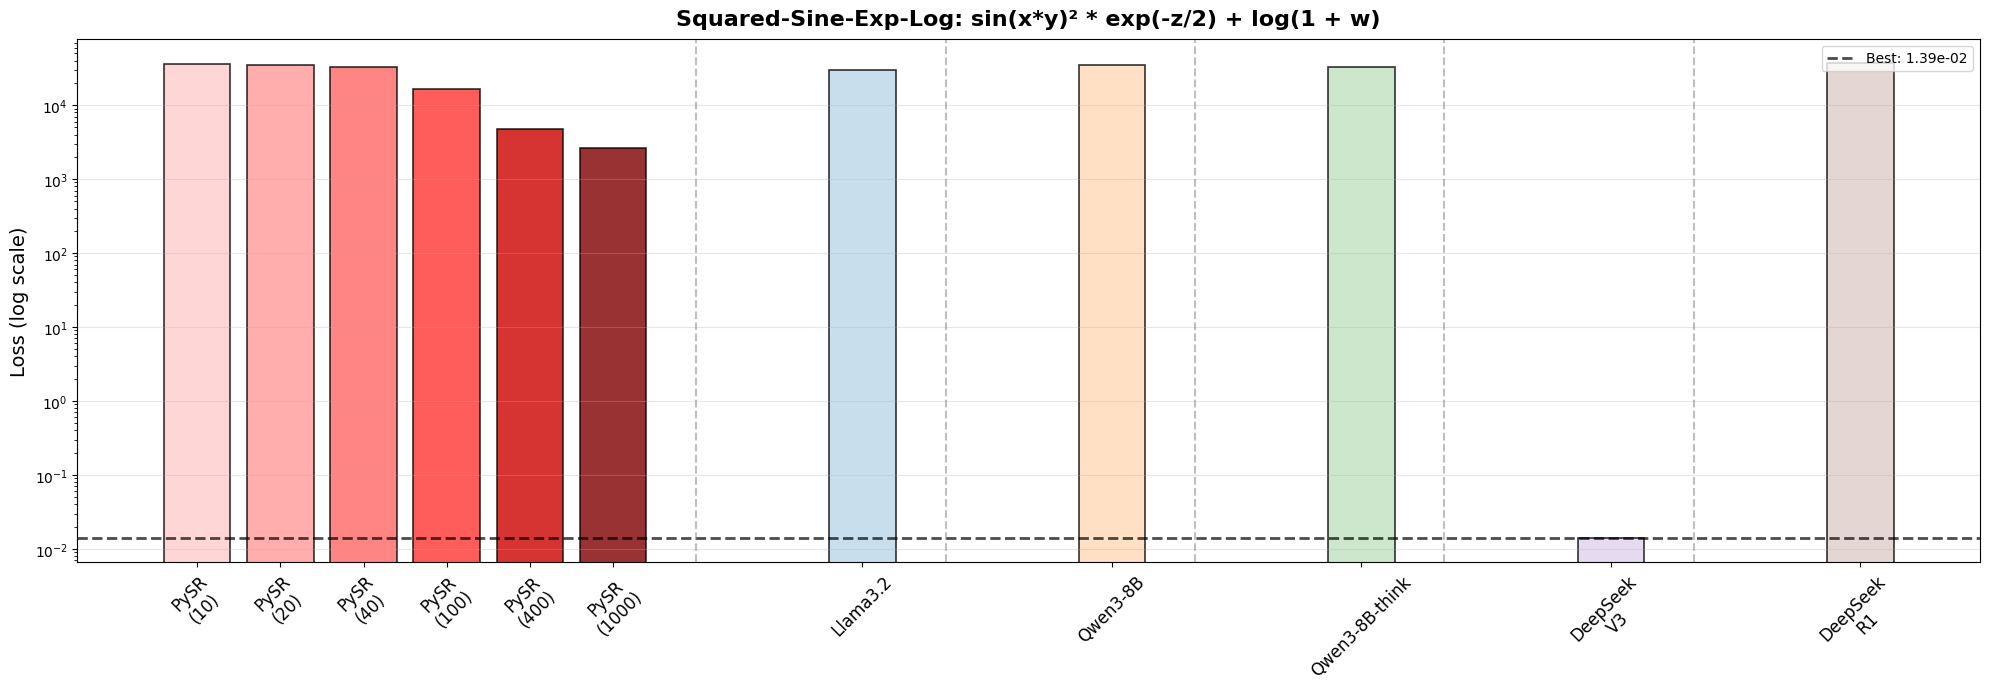

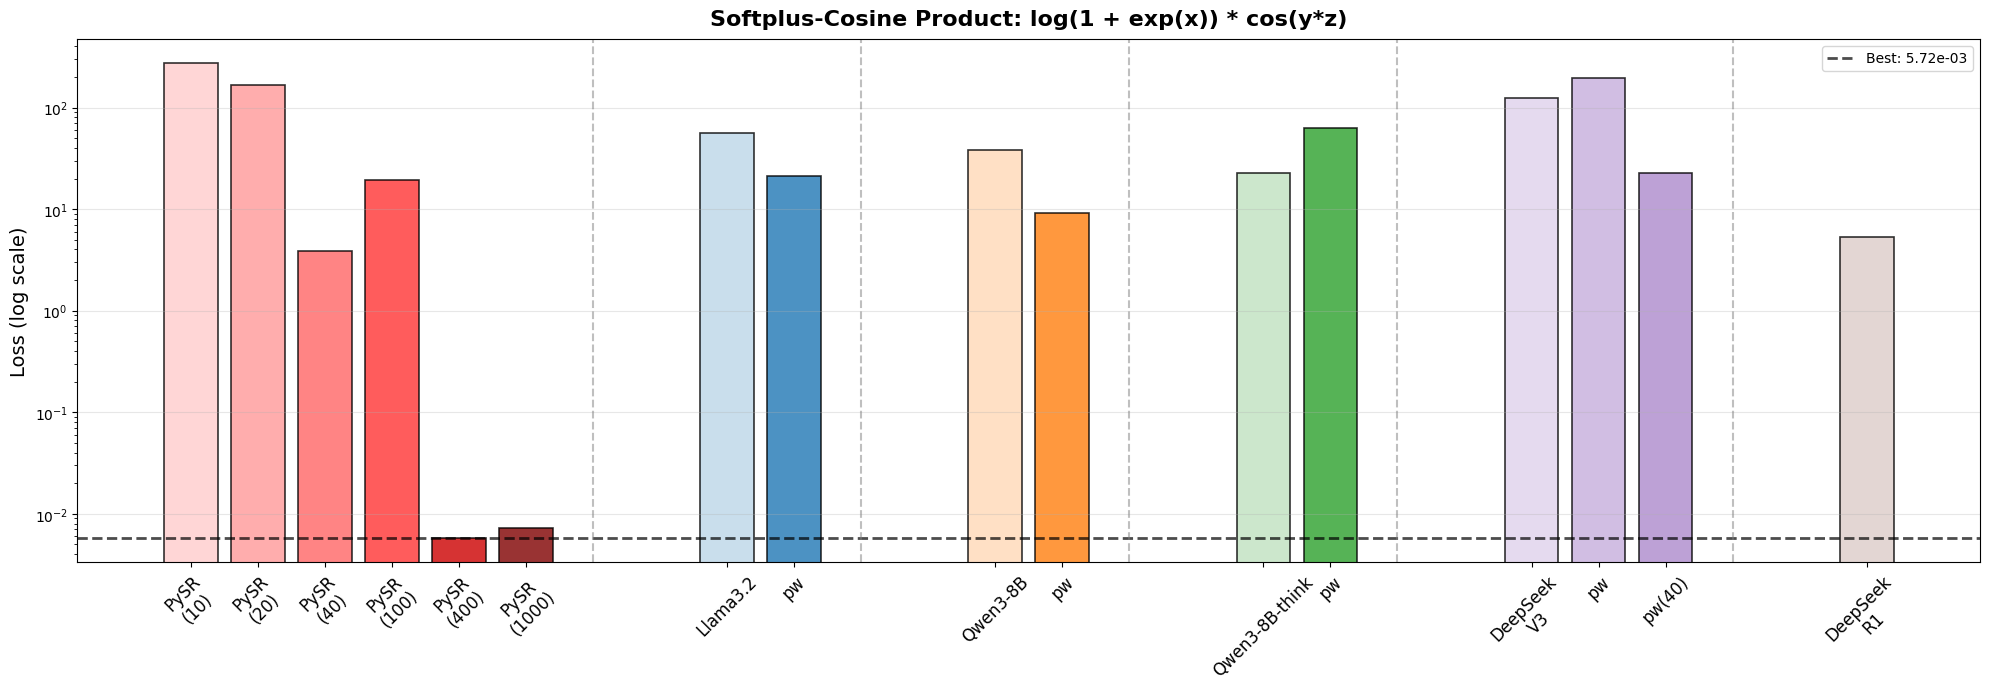

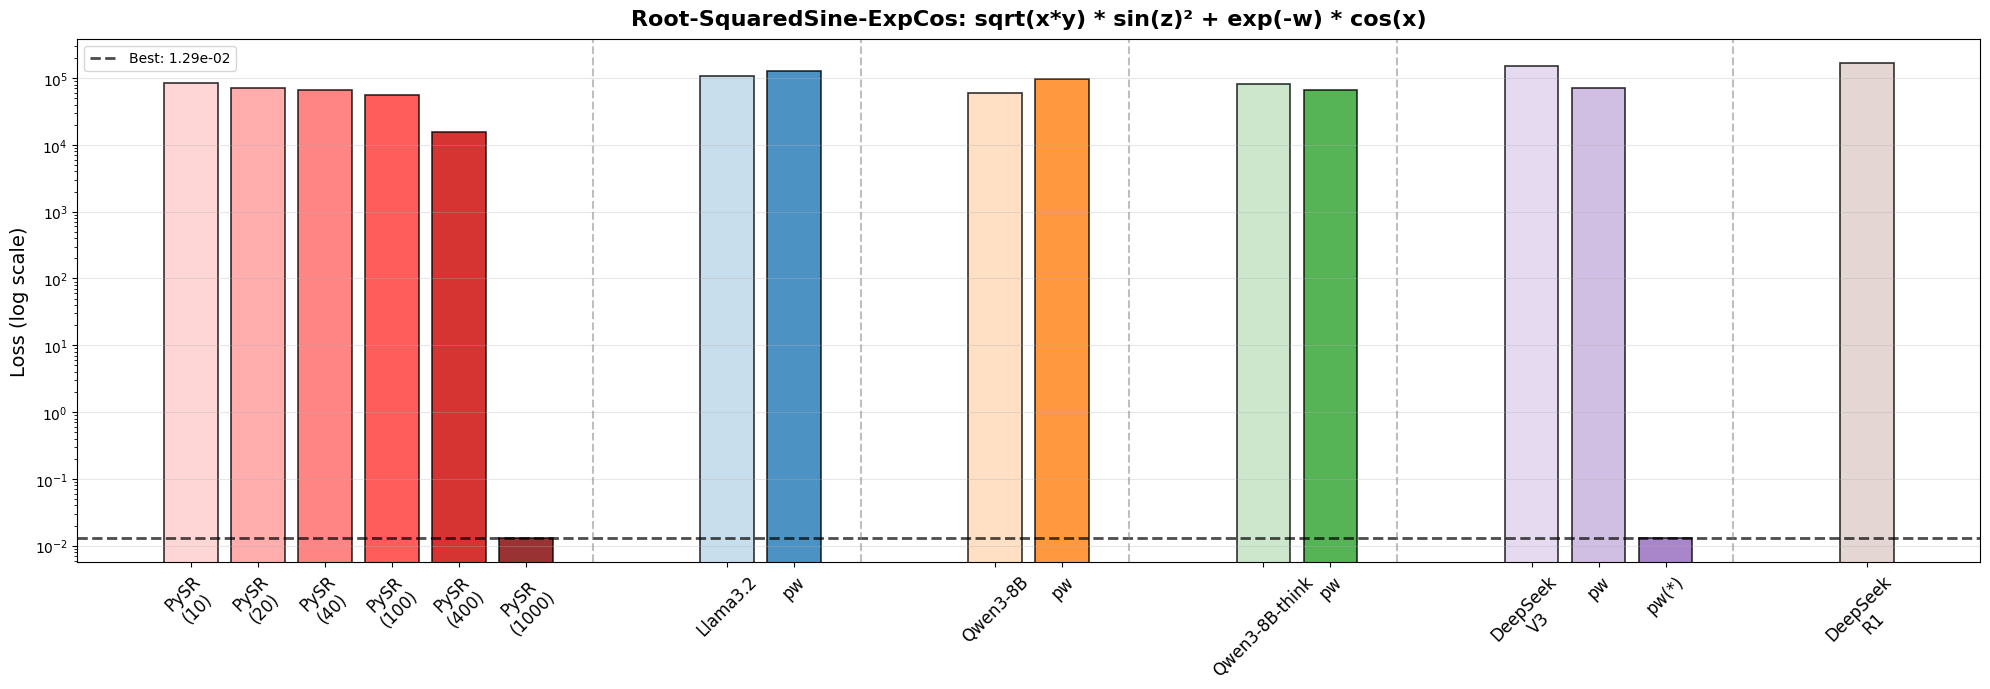

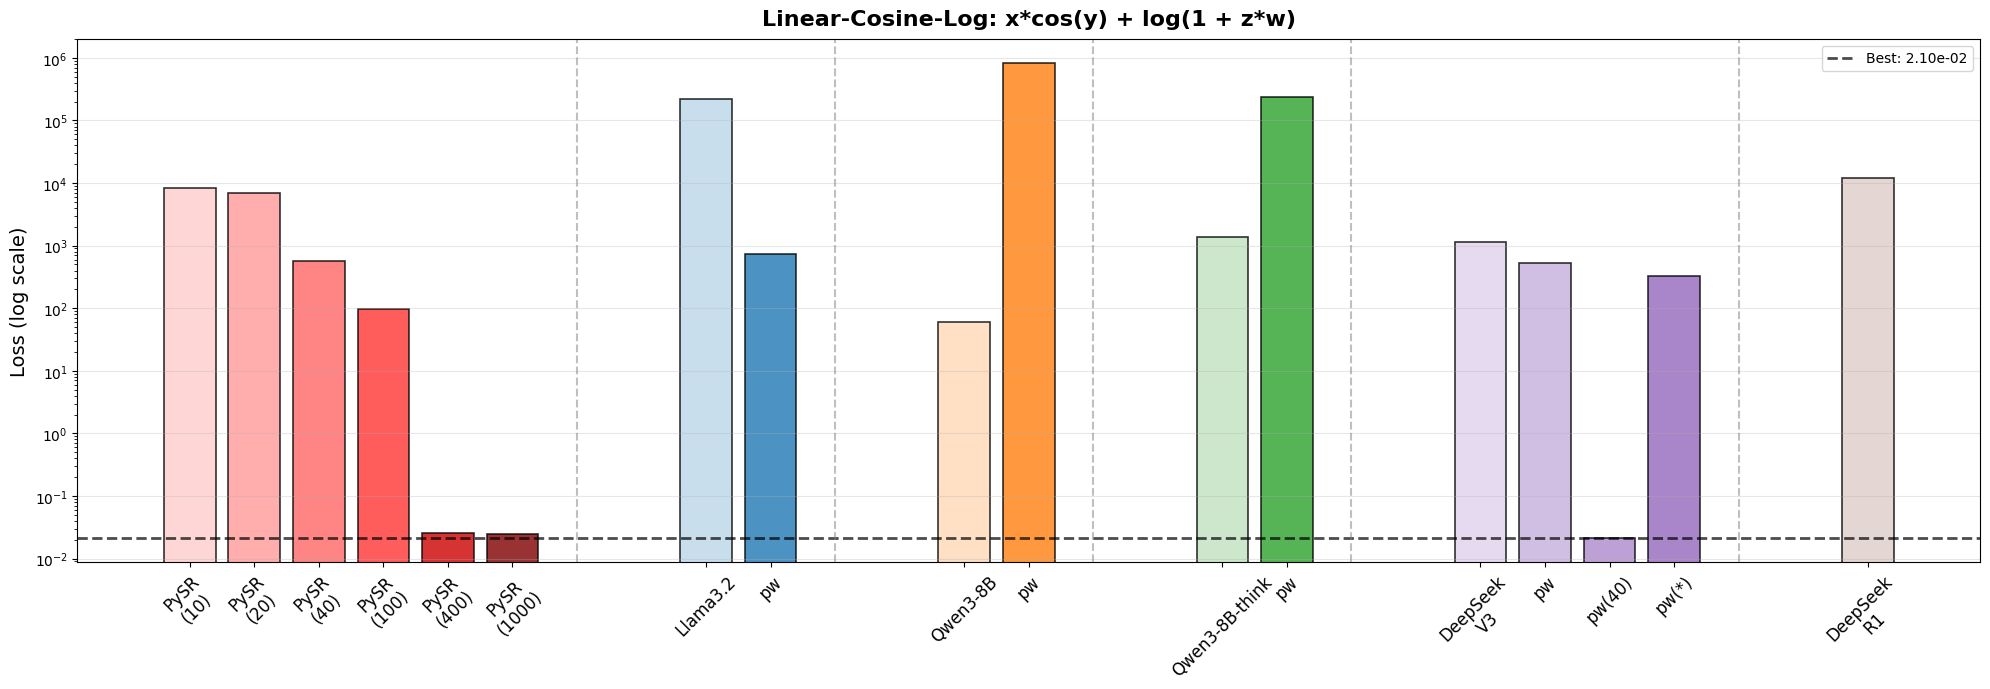

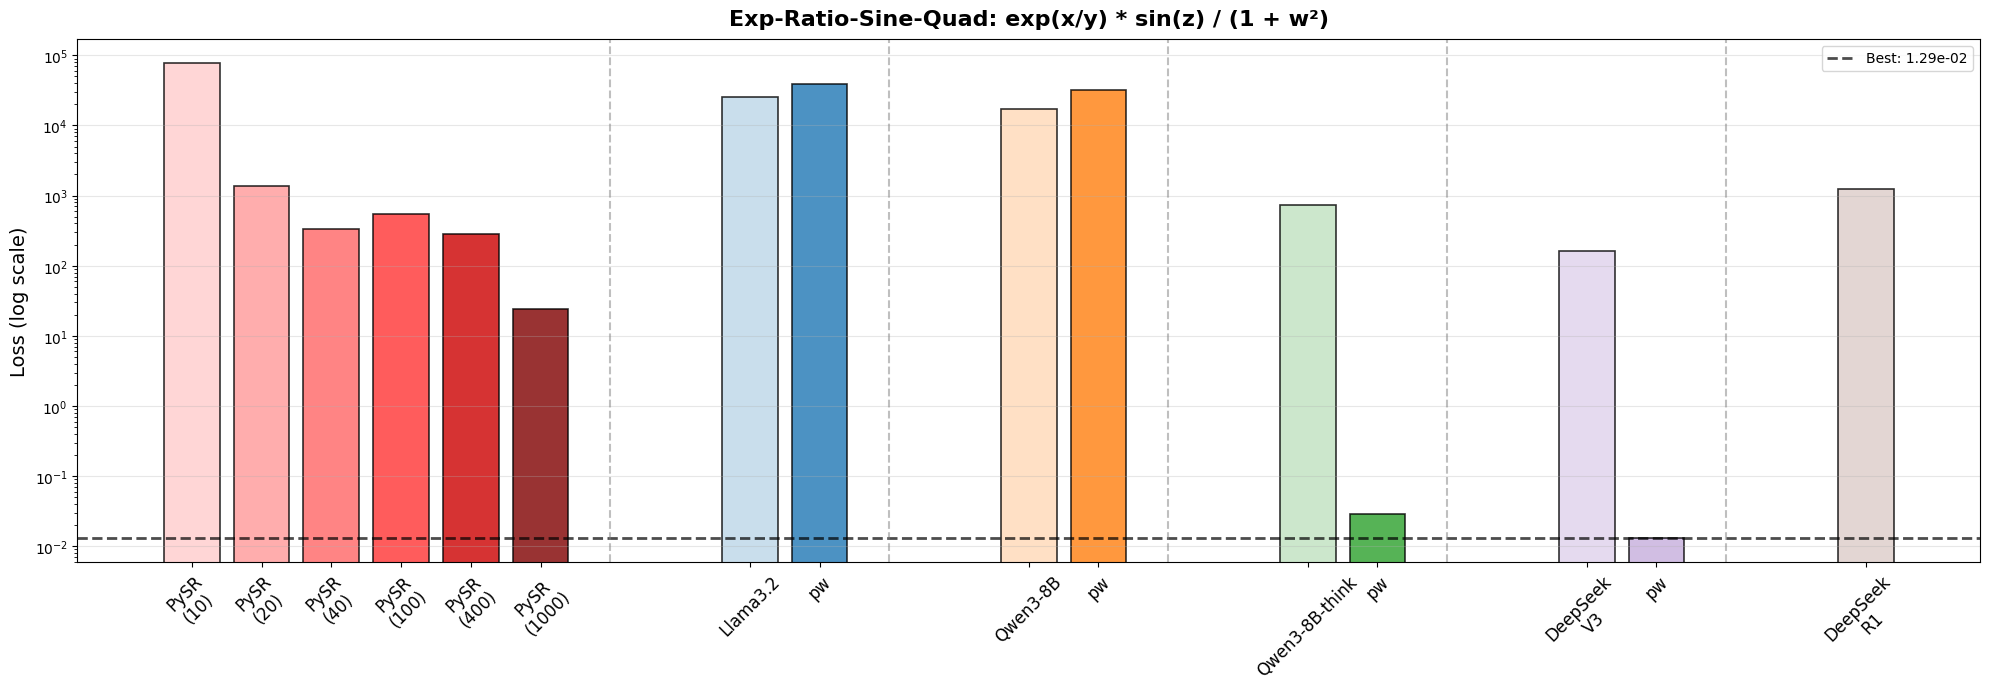

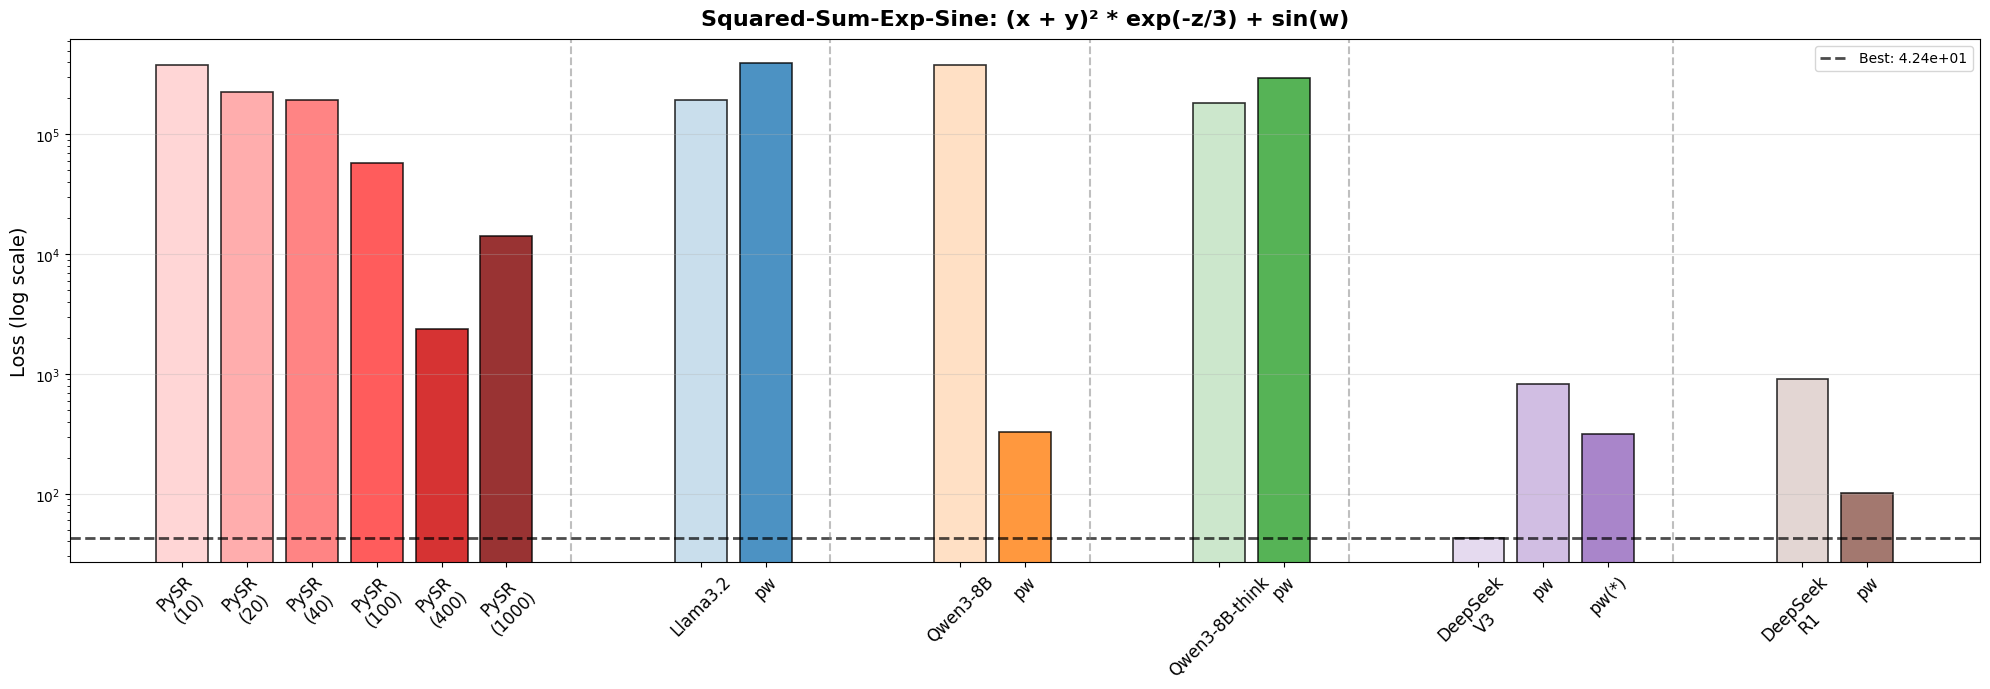

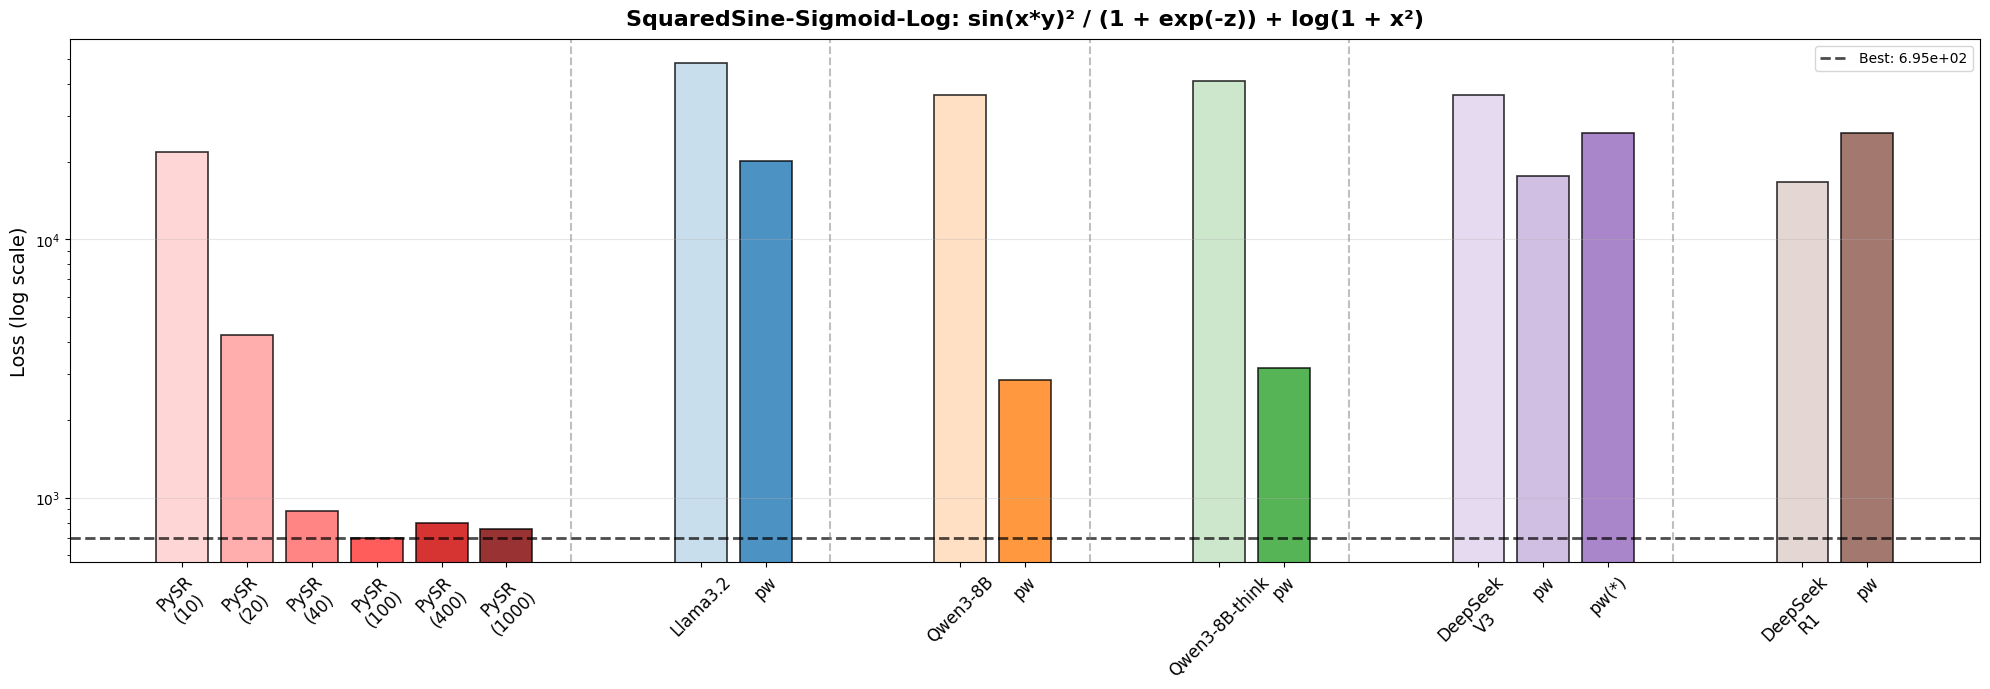

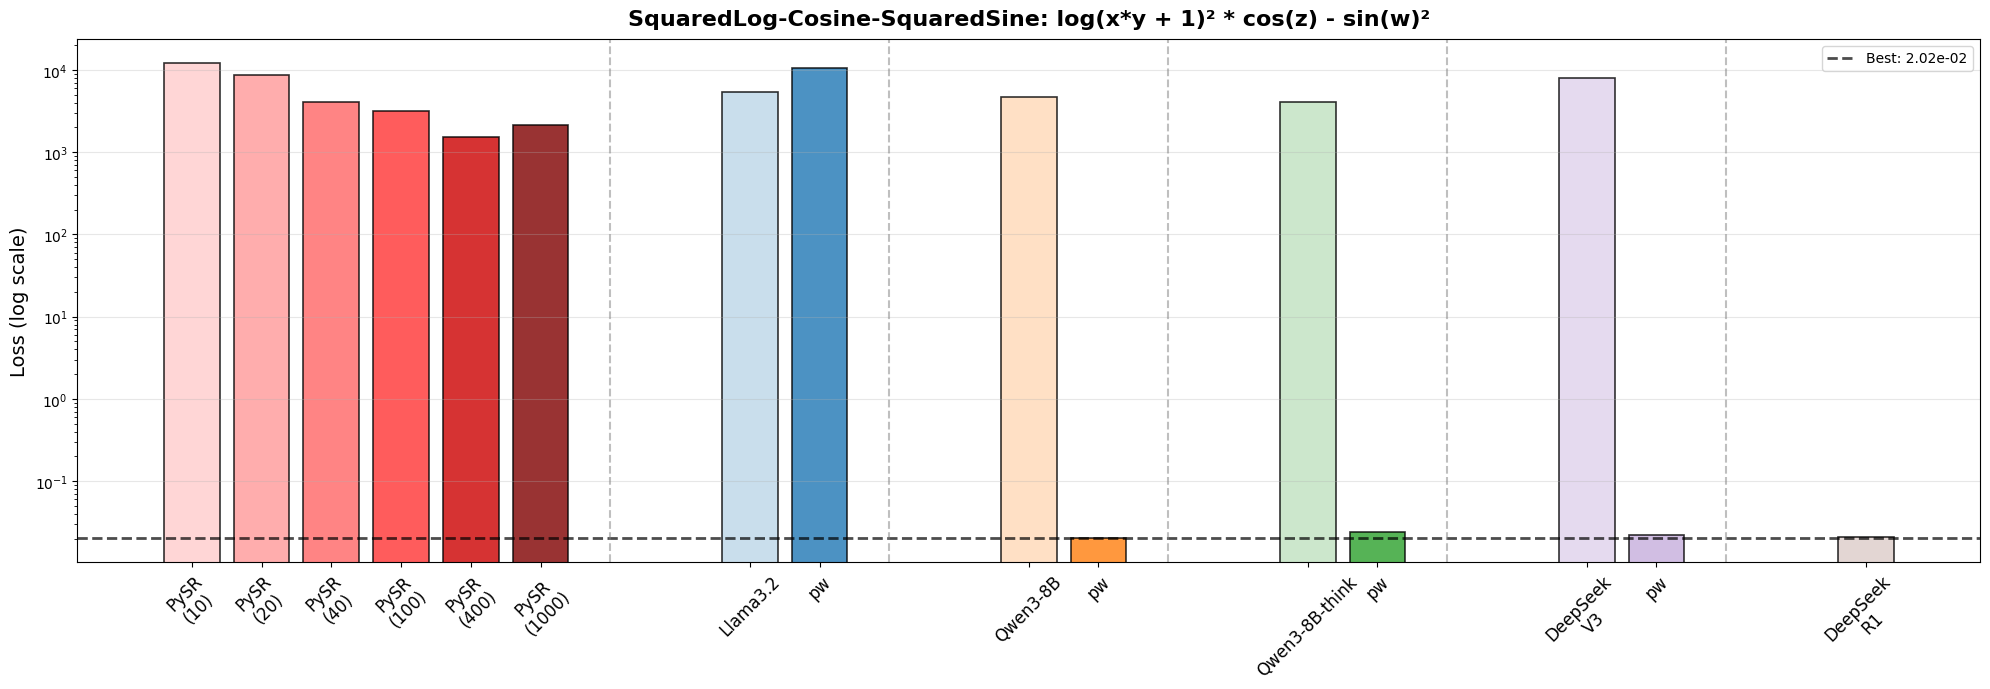

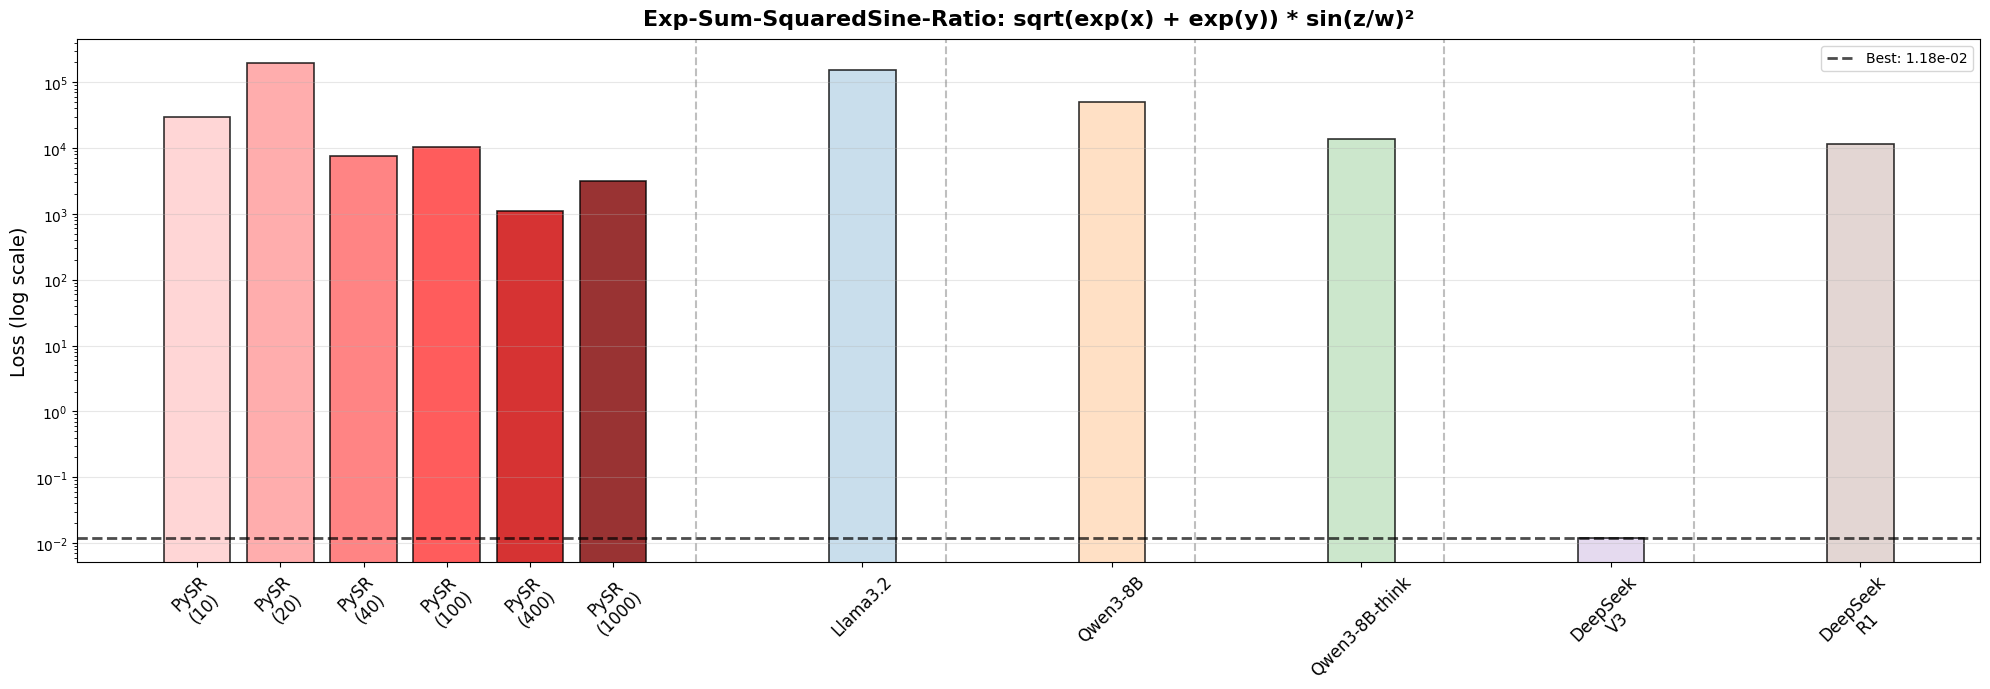

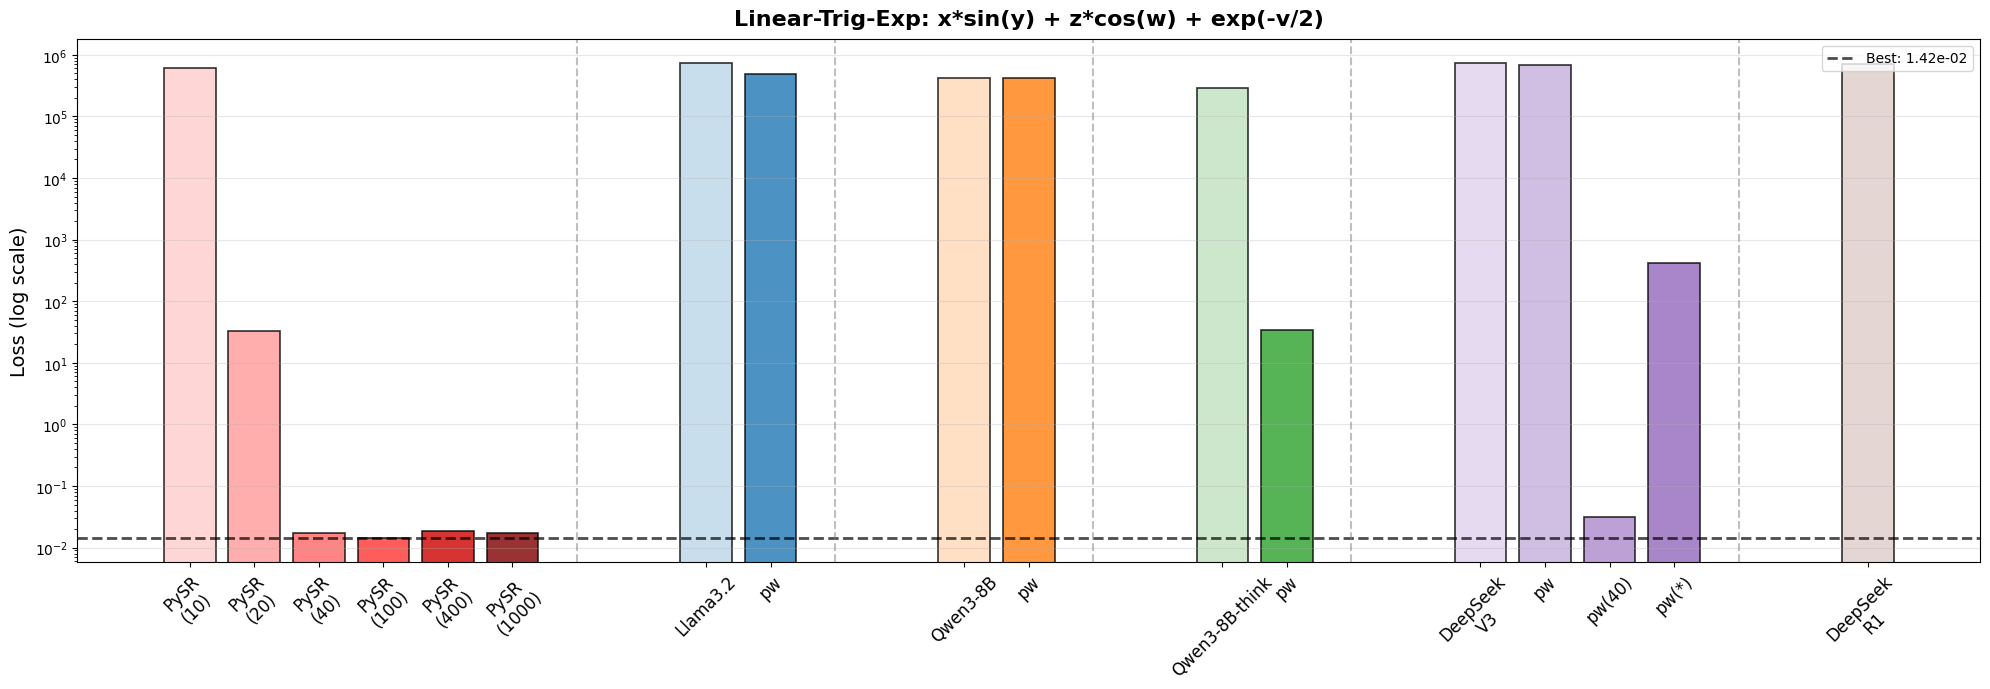

In [123]:
# Create individual equation plots with grouped bars based on lasr_labels structure

# Function to simplify labels (same as above)
def simplify_label(exp_type, exp_key, original_label):
    """Simplify labels: keep full name for pure experiments, only suffix for others"""
    if exp_type == 'pysr':
        return f'PySR\n({exp_key})'
    else:  # lasr
        # Pure experiments (no suffix)
        if exp_key in [0, 1, 2, 3, 4]:
            # For individual plots, keep line break
            return original_label.replace(' ', '\n')
        # Experiments with suffix - show only suffix
        else:
            if 'pw40i' in original_label:
                return 'pw(40)'
            elif 'pw*' in original_label:
                return 'pw(*)'
            elif 'pw' in original_label:
                return 'pw'
            else:
                return original_label

# Define experiment groups based on lasr_labels structure
experiment_groups = {
    'PySR Baselines': {
        'experiments': [],
        'colors': []
    },
    'Llama3.2': {
        'experiments': [],
        'colors': []
    },
    'Qwen3-8B': {
        'experiments': [],
        'colors': []
    },
    'Qwen3-8B-think': {
        'experiments': [],
        'colors': []
    },
    'DeepSeek V3': {
        'experiments': [],
        'colors': []
    },
    'DeepSeek R1': {
        'experiments': [],
        'colors': []
    }
}

# Populate PySR group - add all available PySR iterations
all_pysr_iterations = [10, 20, 40, 100, 400, 1000]
for iterations in all_pysr_iterations:
    experiment_groups['PySR Baselines']['experiments'].append(('pysr', iterations, f'PySR ({iterations})'))
    experiment_groups['PySR Baselines']['colors'].append(exp_colors[f'pysr_{iterations}'])

# Populate LASR groups based on the exact grouping in lasr_labels
# Llama3.2 group
for exp_num in [0, 5]:
    if exp_num in lasr_labels:
        experiment_groups['Llama3.2']['experiments'].append(('lasr', exp_num, lasr_labels[exp_num].replace(' ', '\n')))
        experiment_groups['Llama3.2']['colors'].append(exp_colors[exp_num])

# Qwen3-8B group
for exp_num in [1, 6]:
    if exp_num in lasr_labels:
        experiment_groups['Qwen3-8B']['experiments'].append(('lasr', exp_num, lasr_labels[exp_num].replace(' ', '\n')))
        experiment_groups['Qwen3-8B']['colors'].append(exp_colors[exp_num])

# Qwen3-8B-think group
for exp_num in [2, 7]:
    if exp_num in lasr_labels:
        experiment_groups['Qwen3-8B-think']['experiments'].append(('lasr', exp_num, lasr_labels[exp_num].replace(' ', '\n')))
        experiment_groups['Qwen3-8B-think']['colors'].append(exp_colors[exp_num])

# DeepSeek V3 group
for exp_num in [3, 8, 10, 11]:
    if exp_num in lasr_labels:
        experiment_groups['DeepSeek V3']['experiments'].append(('lasr', exp_num, lasr_labels[exp_num].replace(' ', '\n')))
        experiment_groups['DeepSeek V3']['colors'].append(exp_colors[exp_num])

# DeepSeek R1 group
for exp_num in [4, 12]:
    if exp_num in lasr_labels:
        experiment_groups['DeepSeek R1']['experiments'].append(('lasr', exp_num, lasr_labels[exp_num].replace(' ', '\n')))
        experiment_groups['DeepSeek R1']['colors'].append(exp_colors[exp_num])

# Show all 10 equations (changed from [:3])
for eq_num in all_equations:
    plt.figure(figsize=(20, 7))
    
    # Collect data for this equation
    all_positions = []
    all_heights = []
    all_colors = []
    all_labels = []
    
    current_pos = 0
    group_positions = {}
    
    for group_name, group_data in experiment_groups.items():
        group_start = current_pos
        
        # Only add experiments that have data for this equation
        for i, (exp_type, exp_key, label) in enumerate(group_data['experiments']):
            loss = None
            if exp_type == 'pysr' and exp_key in pysr_data and eq_num in pysr_data[exp_key]:
                loss = pysr_data[exp_key][eq_num]
            elif exp_type == 'lasr' and exp_key in lasr_data and eq_num in lasr_data[exp_key]:
                loss = lasr_data[exp_key][eq_num]
            
            # Only add if there is valid data
            if loss is not None and not np.isnan(loss):
                all_positions.append(current_pos)
                all_heights.append(loss)
                all_colors.append(group_data['colors'][i])
                
                # Apply simplified label
                simplified_label = simplify_label(exp_type, exp_key, label)
                all_labels.append(simplified_label)
                current_pos += 1
        
        # Only record group position if group has data
        if current_pos > group_start:
            group_positions[group_name] = (group_start, current_pos - 1)
            current_pos += 2  # Add larger space between groups
    
    # Plot bars only for experiments with data
    bars = []
    for pos, height, color in zip(all_positions, all_heights, all_colors):
        bar = plt.bar(pos, height, color=color, alpha=0.8, 
                      edgecolor='black', linewidth=1.2, width=0.8)
        bars.extend(bar)
    
    plt.yscale('log')
    plt.ylabel('Loss (log scale)', fontsize=14)
    
    # Find and highlight best performer among valid data
    if all_heights:
        min_height = min(all_heights)
        
        # Add horizontal line at minimum loss
        plt.axhline(y=min_height, color='black', linestyle='--', 
                   linewidth=2, alpha=0.7, label=f'Best: {min_height:.2e}')
        plt.legend()
    
    # Set x-axis labels only for experiments with data - shift them slightly to the right
    if all_positions:
        plt.xticks(all_positions, all_labels, rotation=45, ha='center', fontsize=12)
    else:
        # No data for this equation, hide x-axis ticks
        plt.xticks([])
    
    # Add vertical separator lines between groups
    for i, (group_name, (start, end)) in enumerate(group_positions.items()):
        if i < len(group_positions) - 1:
            plt.axvline(x=end + 1, color='gray', linestyle='--', 
                       linewidth=1.5, alpha=0.5)
    
    plt.grid(True, alpha=0.3, axis='y')
    
    # Set title
    eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Equation {eq_num}'
    eq_formula = equation_info[eq_num]['formula'] if eq_num in equation_info else ''
    plt.title(f'{eq_name}: {eq_formula}', fontsize=16, fontweight='bold', pad=10)
    
    plt.tight_layout()
    plt.show()